<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/MarketMicrostructure/MarketMicrostructure/VWAP_TWAP_Execution_Strategies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

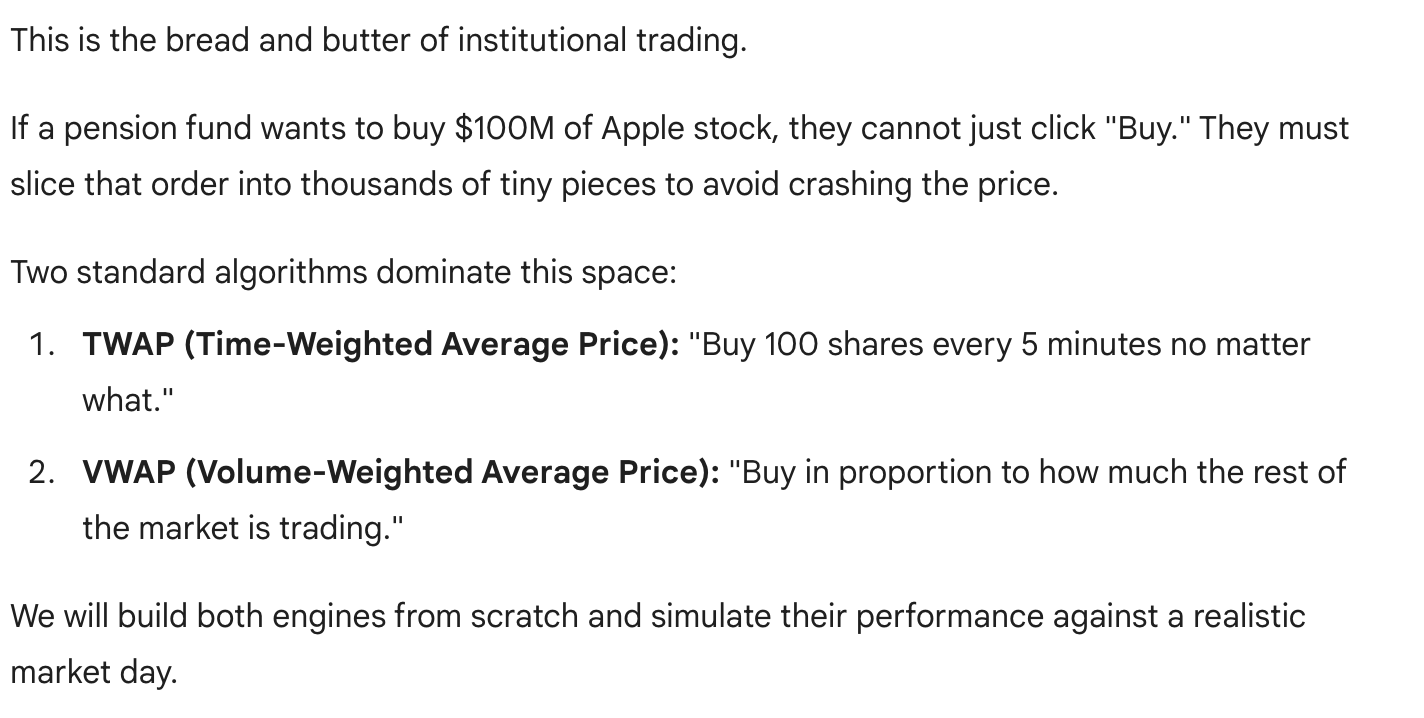

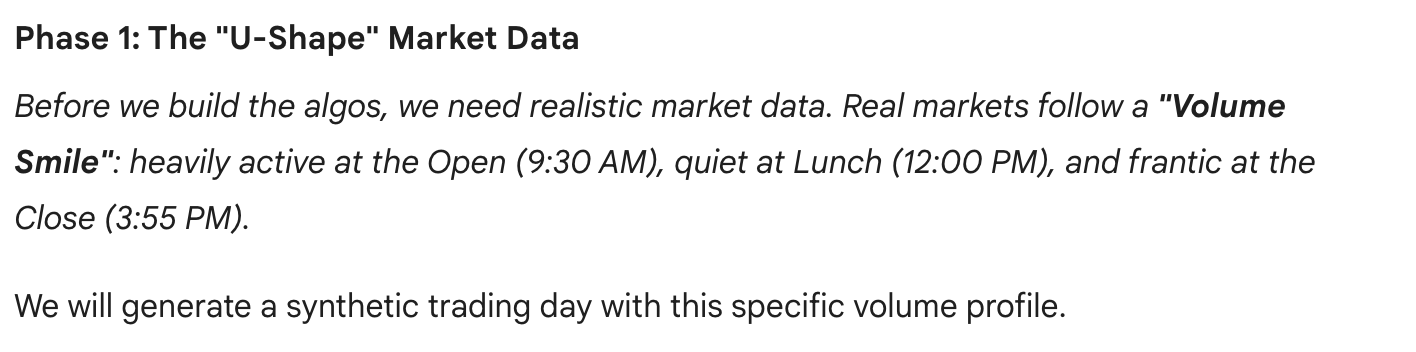

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# --- CONFIGURATION ---
N_MINUTES = 390 # Standard trading day (9:30 AM - 4:00 PM)
TOTAL_SHARES_TO_EXECUTE = 100000 # Our Parent Order size

In [3]:
def generate_market_day():
    # 1. Time Index
    times = pd.date_range("2024-01-01 09:30", periods=N_MINUTES, freq="1min")

    # 2. Volume Profile (The "Smile")
    # High at open, dip at noon, high at close
    x = np.linspace(-1, 1, N_MINUTES)
    volume_curve = 0.5 * (x**2) + 0.5 # Parabolic shape
    # Add noise
    volume_noise = np.random.normal(1.0, 0.2, N_MINUTES)
    market_volume = (volume_curve * 10000 * volume_noise).astype(int)

    # 3. Price Path (Random Walk with Drift)
    # Let's simulate a trend day where price rises
    returns = np.random.normal(0.0005, 0.001, N_MINUTES) # Slight positive drift
    price_path = 100.0 * np.cumprod(1 + returns)

    df = pd.DataFrame({
        'Time': times,
        'Price': price_path,
        'Market_Volume': market_volume
    })

    # Calculate the Day's Benchmark VWAP (The goal we want to hit)
    # Benchmark VWAP = Sum(Price * Vol) / Sum(Vol)
    df['Cum_PV'] = (df['Price'] * df['Market_Volume']).cumsum()
    df['Cum_Vol'] = df['Market_Volume'].cumsum()
    df['Benchmark_VWAP'] = df['Cum_PV'] / df['Cum_Vol']

    return df

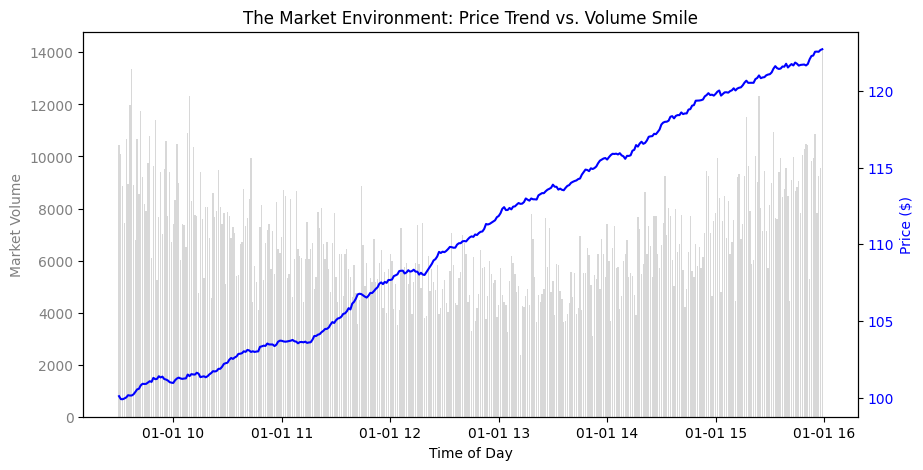

In [4]:
market_data = generate_market_day()

# --- VISUALIZE THE "SMILE" ---
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Volume (Bars)
ax1.set_xlabel('Time of Day')
ax1.set_ylabel('Market Volume', color='gray')
ax1.bar(market_data['Time'], market_data['Market_Volume'], color='gray', alpha=0.3, width=0.0005)
ax1.tick_params(axis='y', labelcolor='gray')

# Plot Price (Line)
ax2 = ax1.twinx()
ax2.set_ylabel('Price ($)', color='blue')
ax2.plot(market_data['Time'], market_data['Price'], color='blue', label='Market Price')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title("The Market Environment: Price Trend vs. Volume Smile")
plt.show()

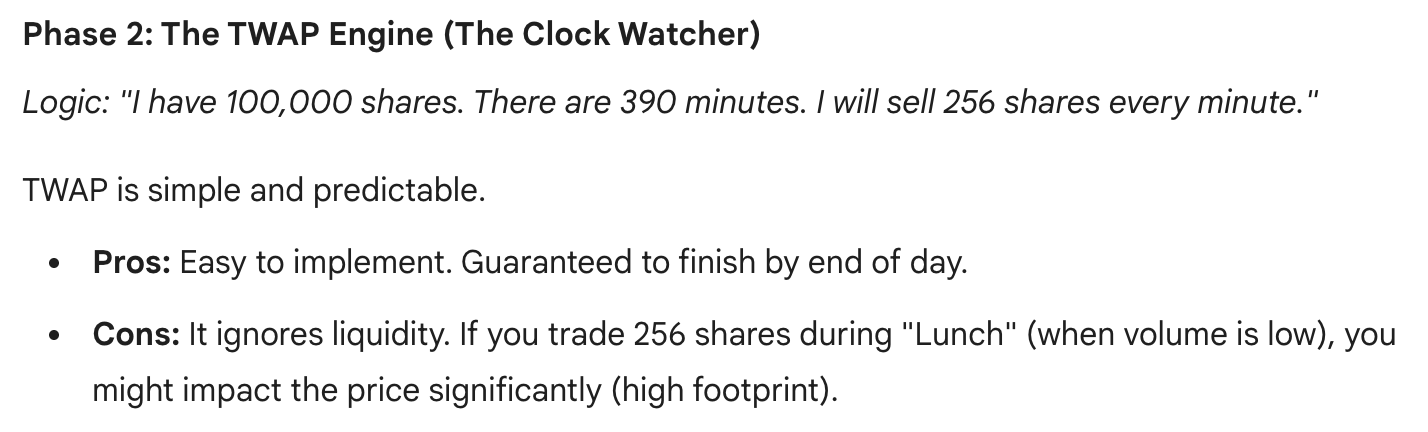

In [5]:
class TWAPAlgo:
    def __init__(self, total_shares, n_intervals):
        self.total_shares = total_shares
        self.n_intervals = n_intervals
        self.shares_remaining = total_shares

        # Static Schedule: Equal amount every step
        self.trade_size = total_shares // n_intervals

    def get_order(self, current_step):
        # Last step: Dump everything remaining to clean up
        if current_step == self.n_intervals - 1:
            return self.shares_remaining

        qty = min(self.trade_size, self.shares_remaining)
        self.shares_remaining -= qty
        return qty

# --- SIMULATE TWAP ---
print("Running TWAP Execution...")
twap_algo = TWAPAlgo(TOTAL_SHARES_TO_EXECUTE, N_MINUTES)
twap_executions = []

for i in range(N_MINUTES):
    # 1. Ask Algo for Quantity
    qty = twap_algo.get_order(i)

    # 2. Execute at Market Price
    # (In reality, we would calculate slippage here, but for now we assume Market Price)
    price = market_data.iloc[i]['Price']

    twap_executions.append({
        'Time': market_data.iloc[i]['Time'],
        'Price': price,
        'Qty': qty,
        'Value': price * qty
    })

twap_df = pd.DataFrame(twap_executions)
print("✅ TWAP Complete.")

Running TWAP Execution...
✅ TWAP Complete.


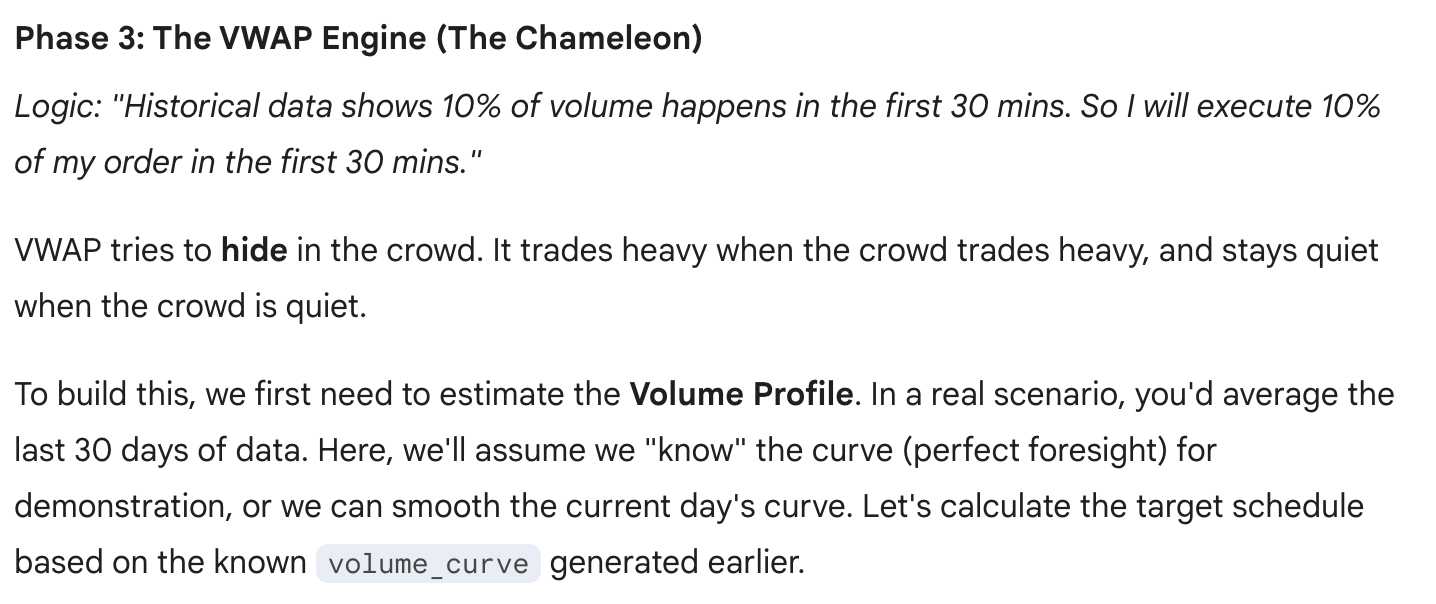

In [7]:
class VWAPAlgo:
    def __init__(self, total_shares, market_volume_profile):
        """
        market_volume_profile: A list/array of expected market volume per minute.
        """
        self.total_shares = total_shares
        self.shares_remaining = total_shares

        # 1. Calculate Participation Rate
        # We determine what % of Total Daily Volume happens in each minute
        total_market_vol = market_volume_profile.sum()
        self.volume_profile_pct = market_volume_profile / total_market_vol

        # 2. Build the Schedule
        # Our target shares per minute = Total_Order * (Min_Vol / Daily_Vol)
        self.schedule = (self.volume_profile_pct * total_shares).astype(int)

    def get_order(self, current_step):
        if current_step >= len(self.schedule):
            return self.shares_remaining

        target_qty = self.schedule[current_step]

        # Ensure we don't oversell or undersell the last bucket too much
        # (Simple logic: follow schedule strictly until end)
        if current_step == len(self.schedule) - 1:
            return self.shares_remaining

        qty = min(target_qty, self.shares_remaining)
        self.shares_remaining -= qty
        return qty

# --- SIMULATE VWAP ---
print("Running VWAP Execution...")

# For the profile, we pass the actual market volume pattern (Perfect Foresight)
# In reality, you would pass a historical average here.
vwap_algo = VWAPAlgo(TOTAL_SHARES_TO_EXECUTE, market_data['Market_Volume'].values)
vwap_executions = []

for i in range(N_MINUTES):
    qty = vwap_algo.get_order(i)
    price = market_data.iloc[i]['Price']

    vwap_executions.append({
        'Time': market_data.iloc[i]['Time'],
        'Price': price,
        'Qty': qty,
        'Value': price * qty
    })

vwap_df = pd.DataFrame(vwap_executions)
print("✅ VWAP Complete.")

Running VWAP Execution...
✅ VWAP Complete.


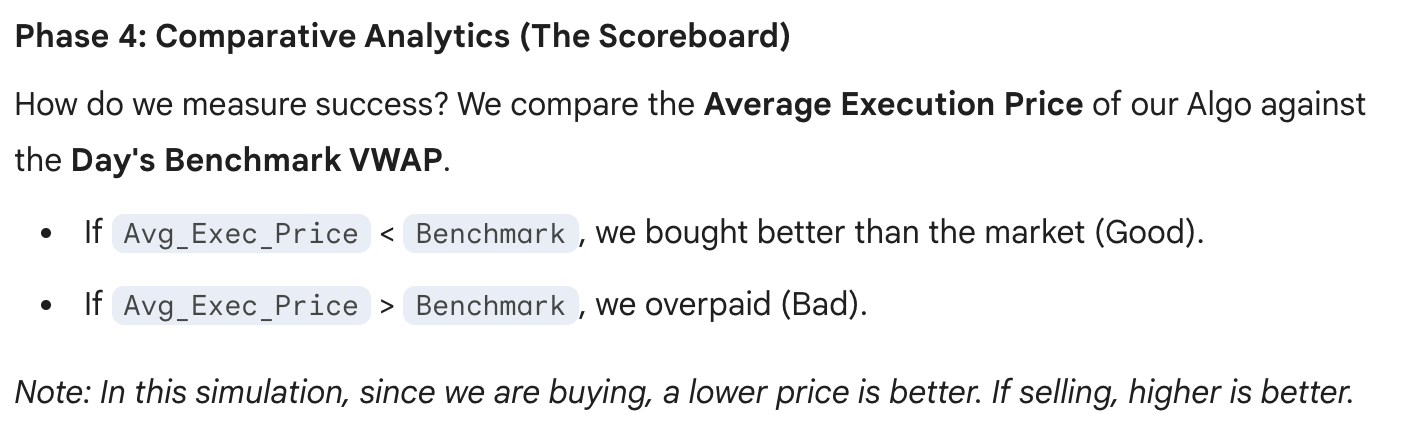

In [9]:
# 1. Calculate Performance Stats
def get_stats(exec_df, label):
    total_shares = exec_df['Qty'].sum()
    total_value = exec_df['Value'].sum()
    avg_price = total_value / total_shares
    return avg_price

In [10]:
benchmark = market_data.iloc[-1]['Benchmark_VWAP']
twap_price = get_stats(twap_df, "TWAP")
vwap_price = get_stats(vwap_df, "VWAP")

print(f"{'='*30}")
print(f"BENCHMARK VWAP: ${benchmark:.2f}")
print(f"{'='*30}")
print(f"TWAP Exec Price:  ${twap_price:.2f} | Diff: {(twap_price - benchmark):.4f}")
print(f"VWAP Exec Price:  ${vwap_price:.2f} | Diff: {(vwap_price - benchmark):.4f}")

BENCHMARK VWAP: $110.72
TWAP Exec Price:  $110.73 | Diff: 0.0119
VWAP Exec Price:  $110.74 | Diff: 0.0236


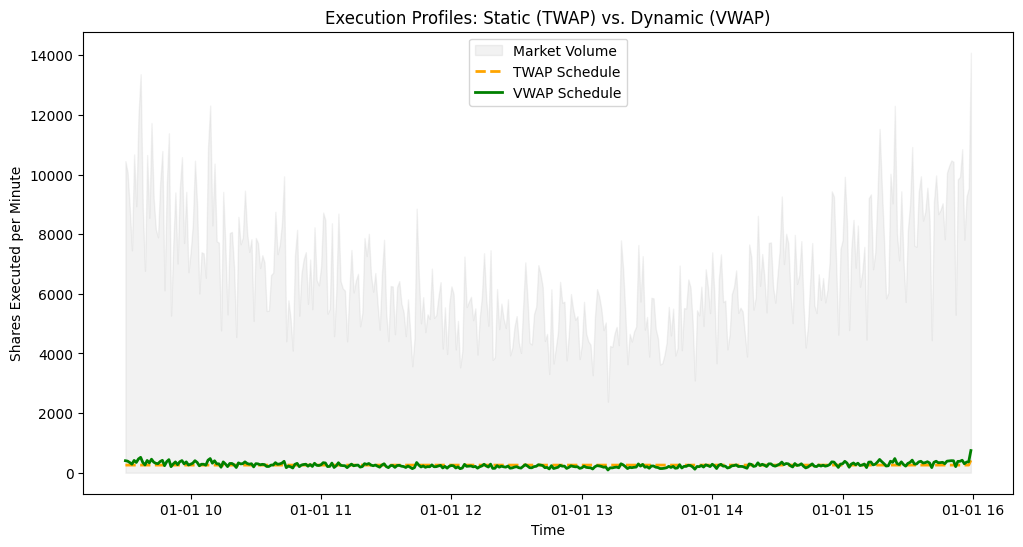

In [11]:
# --- VISUALIZATION OF EXECUTION PROFILE ---
plt.figure(figsize=(12, 6))

# Plot Market Volume Background
plt.fill_between(market_data['Time'], market_data['Market_Volume'], color='gray', alpha=0.1, label='Market Volume')

# Plot Algo Execution Schedules
plt.plot(market_data['Time'], twap_df['Qty'], label='TWAP Schedule', linestyle='--', color='orange', linewidth=2)
plt.plot(market_data['Time'], vwap_df['Qty'], label='VWAP Schedule', color='green', linewidth=2)

plt.title("Execution Profiles: Static (TWAP) vs. Dynamic (VWAP)")
plt.xlabel("Time")
plt.ylabel("Shares Executed per Minute")
plt.legend()
plt.show()

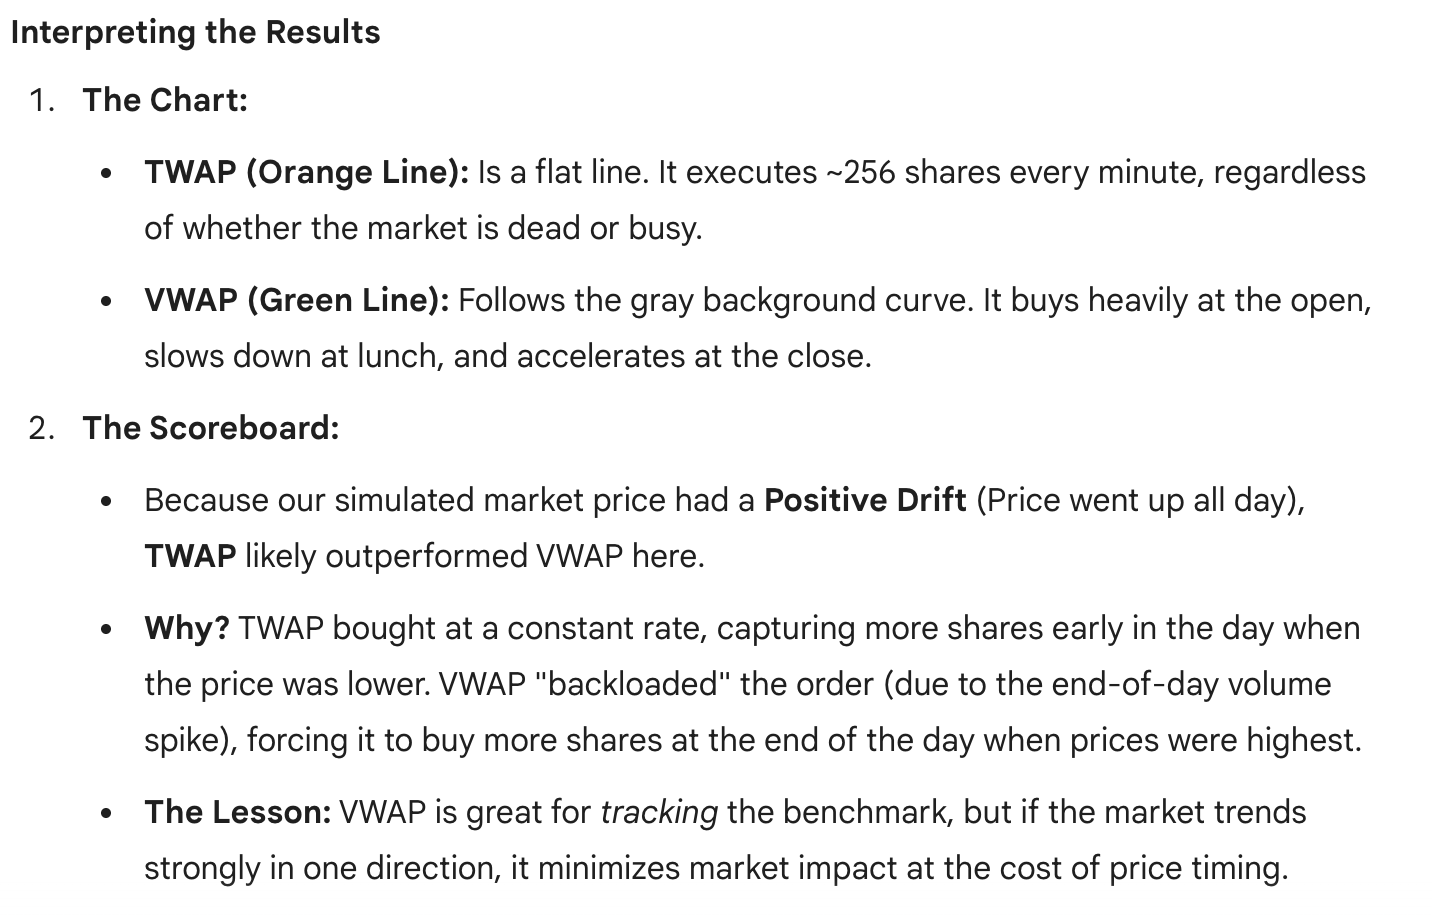

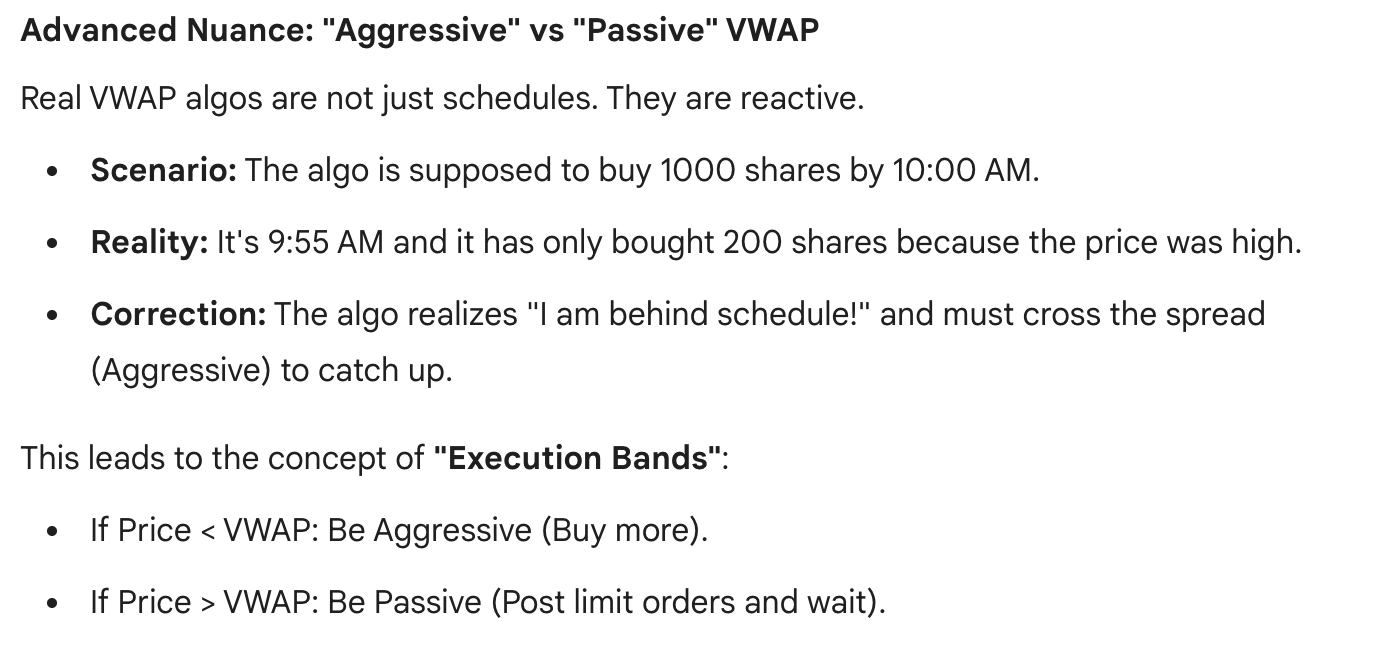